*CAR PRICE PREDICTION*

The CarDekho dataset contains information about used cars sold in India. It has details like the car's brand, year, kilometers driven, fuel type, transmission, engine size, and power. Our goal is to use these details to predict the selling price of a car. It is a real world dataset which means the features have strong and logical relationships with the price, making it a great dataset for building a regression model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv(r"C:\Users\laksh\Downloads\cardekho.csv")

In [3]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [4]:
df.shape

(8128, 12)

In [5]:
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

In [6]:
df=df.dropna()

In [7]:
df=df.drop_duplicates()

In [8]:
df = df.drop(columns=['seats'])

In [9]:
print(df.shape)

(6718, 11)


In [10]:
# Extract brand name from name column
df['brand'] = df['name'].apply(lambda x: x.split()[0])
df = df.drop(columns=['name'])

In [11]:
print(df.isnull().sum())
df.head()

year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
brand                 0
dtype: int64


,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,brand
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,Maruti
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,Skoda
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,Honda
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,Hyundai
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,Maruti


EDA

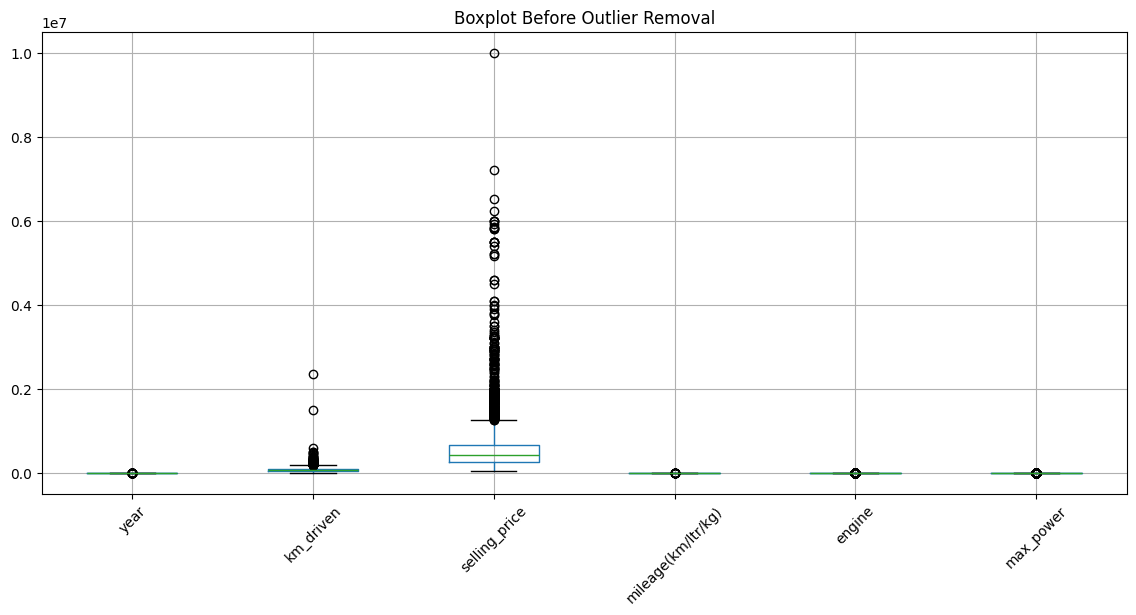

Rounds needed: 4
Rows after removing outliers: 4979


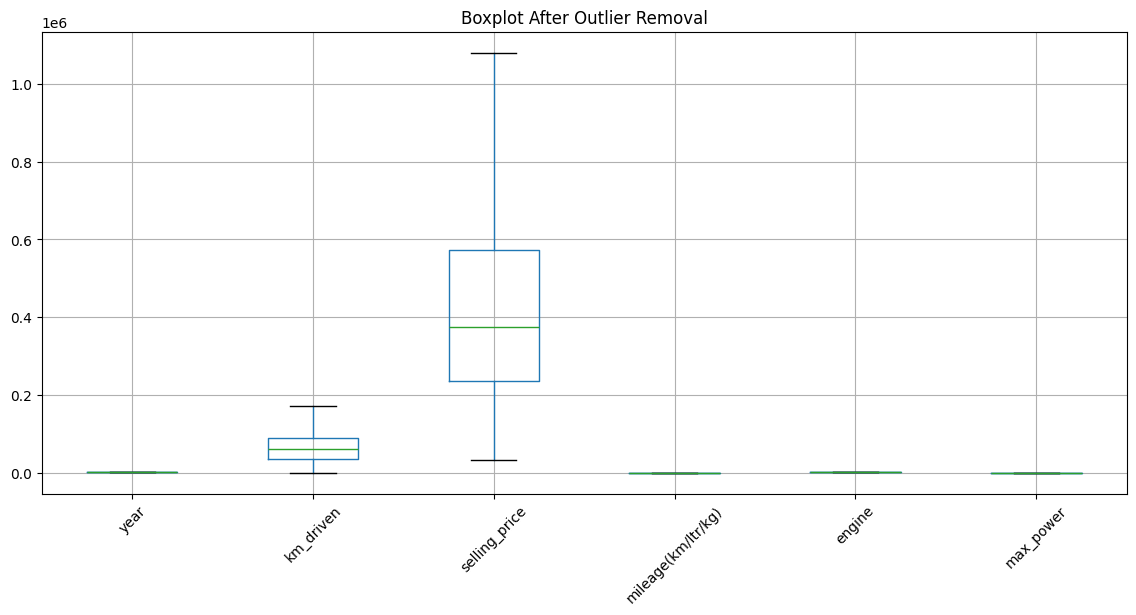

In [12]:
# Outlier Detection
numeric_cols = ['year', 'km_driven', 'selling_price', 'mileage(km/ltr/kg)', 'engine', 'max_power']

# Convert to numeric
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna()

# Before Outlier Removal
df[numeric_cols].boxplot(figsize=(14,6))
plt.xticks(rotation=45)
plt.title("Boxplot Before Outlier Removal")
plt.show()

# Remove outliers in multiple rounds
rounds = 0
while True:
    total_outliers = set()
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outlier_index = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)].index
        total_outliers.update(outlier_index)
    if len(total_outliers) == 0:
        break
    df = df.drop(index=total_outliers).reset_index(drop=True)
    rounds += 1

print("Rounds needed:", rounds)
print("Rows after removing outliers:", len(df))

# After Outlier Removal
df[numeric_cols].boxplot(figsize=(14,6))
plt.xticks(rotation=45)
plt.title("Boxplot After Outlier Removal")
plt.show()

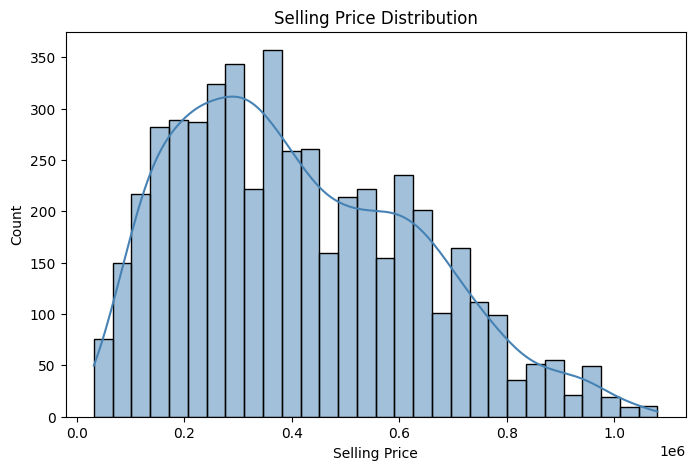

In [13]:
# Price Distribution:
plt.figure(figsize=(8,5))
sns.histplot(df['selling_price'], bins=30, kde=True, color='steelblue')
plt.title('Selling Price Distribution')
plt.xlabel('Selling Price')
plt.show()

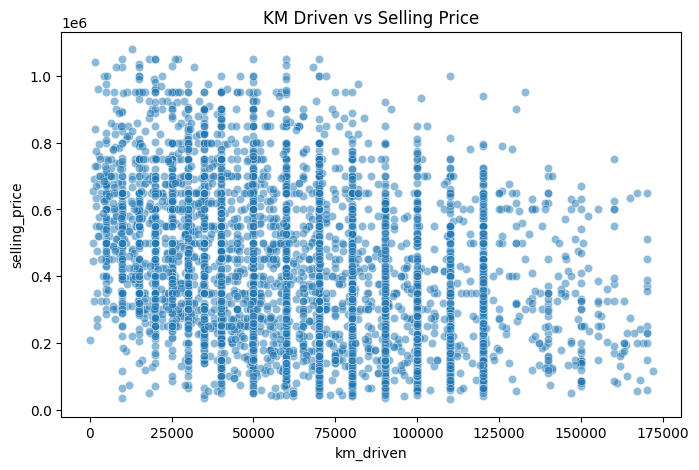

In [14]:
# KM Driven vs Price:
plt.figure(figsize=(8,5))
sns.scatterplot(x='km_driven', y='selling_price', data=df, alpha=0.5)
plt.title('KM Driven vs Selling Price')
plt.show()

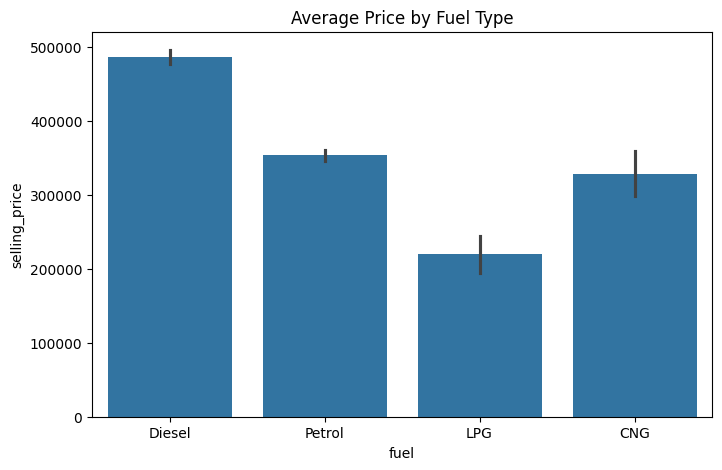

In [15]:
# Average Price by Fuel Type:
plt.figure(figsize=(8,5))
sns.barplot(x='fuel', y='selling_price', data=df)
plt.title('Average Price by Fuel Type')
plt.show()

In [16]:
# FEATURE ENGINEERING
le = LabelEncoder()
df['fuel'] = le.fit_transform(df['fuel'])
df['seller_type'] = le.fit_transform(df['seller_type'])
df['transmission'] = le.fit_transform(df['transmission'])
df['owner'] = le.fit_transform(df['owner'])
df['brand'] = le.fit_transform(df['brand'])

print(df.head())

   year  selling_price  km_driven  fuel  seller_type  transmission  owner  \
0  2014         450000     145500     1            1             1      0   
1  2014         370000     120000     1            1             1      2   
2  2006         158000     140000     3            1             1      3   
3  2010         225000     127000     1            1             1      0   
4  2007         130000     120000     3            1             1      0   

   mileage(km/ltr/kg)  engine  max_power  brand  
0               23.40  1248.0      74.00      8  
1               21.14  1498.0     103.52     11  
2               17.70  1497.0      78.00      4  
3               23.00  1396.0      90.00      5  
4               16.10  1298.0      88.20      8  


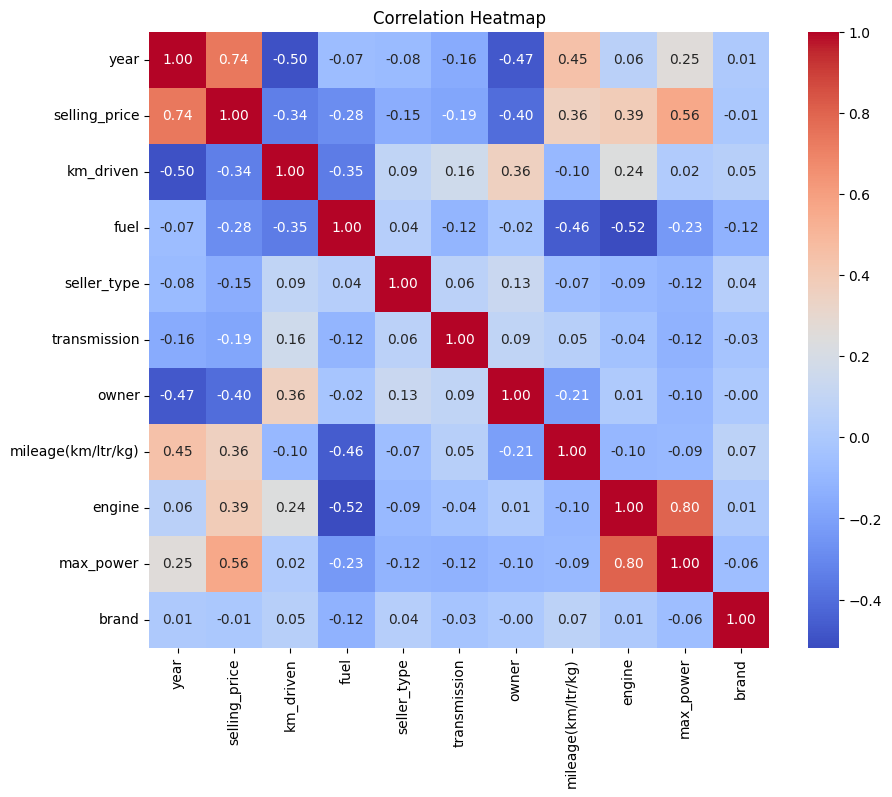

In [18]:
# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

TRAIN TEST SPLIT

In [19]:
X = df.drop(columns=['selling_price'])
y = df['selling_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("=== Linear Regression ===")
print("R2 Score:", round(r2_score(y_test, lr_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, lr_pred)), 2))


=== Linear Regression ===
R2 Score: 0.7393
RMSE: 109557.93


In [21]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SVR Model
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)
svr_pred = svr.predict(X_test_scaled)

print("=== Support Vector Regression ===")
print("R2 Score:", round(r2_score(y_test, svr_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, svr_pred)), 2))

=== Support Vector Regression ===
R2 Score: -0.0225
RMSE: 216979.95


In [22]:
from sklearn.tree import DecisionTreeRegressor

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("=== Decision Tree ===")
print("R2 Score:", round(r2_score(y_test, dt_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, dt_pred)), 2))

=== Decision Tree ===
R2 Score: 0.7874
RMSE: 98938.55


In [23]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Regression
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=== Random Forest Regression ===")
print("R2 Score:", round(r2_score(y_test, rf_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, rf_pred)), 2))

=== Random Forest Regression ===
R2 Score: 0.8819
RMSE: 73740.76


In [24]:
from sklearn.ensemble import AdaBoostRegressor

# AdaBoost Regression
ada = AdaBoostRegressor(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)

print("=== AdaBoost Regression ===")
print("R2 Score:", round(r2_score(y_test, ada_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, ada_pred)), 2))

=== AdaBoost Regression ===
R2 Score: 0.7888
RMSE: 98611.07


In [25]:
from sklearn.linear_model import BayesianRidge

# Bayesian Ridge Regression
bay = BayesianRidge()
bay.fit(X_train, y_train)
bay_pred = bay.predict(X_test)

print("=== Bayesian Ridge Regression ===")
print("R2 Score:", round(r2_score(y_test, bay_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, bay_pred)), 2))

=== Bayesian Ridge Regression ===
R2 Score: 0.7395
RMSE: 109515.61
